<a href="https://colab.research.google.com/github/tsjmaryam/breastmnist_multimodal_pipeline/blob/main/breastmnist_llm_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Multimodal AI Pipeline for Breast Tumor Classification

This notebook explores how deep learning and large language models can be combined to support medical imaging analysis.

The system uses:
- **BreastMNIST dataset** (MedMNIST)
- **CNN model in PyTorch** for tumor classification
- **Qwen LLM** to generate interpretable explanations of results

Goal: explore how multimodal AI systems can improve interpretability in medical AI.

Author: Maryam Shahbaz Ali



## Notebook Structure

1. Environment Setup  
2. Dataset Loading (BreastMNIST)  
3. Data Preprocessing  
4. CNN Model Architecture  
5. Model Training  
6. Model Evaluation  
7. LLM-based Explanation Generation

## Environment Setup
Run the following cell in Google Colab to install the required packages. Restart the runtime once if prompted.

In [ ]:
# Install dependencies
!pip -q install medmnist torch torchvision transformers accelerate tqdm matplotlib scikit-learn pillow

In [ ]:
# Core libraries
import os
import sys
import platform
import requests
import numpy as np
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Dataset and utilities
from tqdm import tqdm
import medmnist
from medmnist import BreastMNIST, INFO

# Evaluation
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score, classification_report

# LLM tools
from transformers import AutoTokenizer, AutoModelForCausalLM

## Environment Check
This section verifies the runtime configuration and hardware availability.

In [ ]:
print("Python:", sys.version)
print("Platform:", platform.platform())
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
PyTorch: 2.10.0+cpu
CUDA available: False
Using device: cpu


## Dataset: BreastMNIST

BreastMNIST is a binary classification dataset from MedMNIST containing breast ultrasound images labeled as benign or malignant.

In [ ]:
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.0 MB/s eta 0:00:00


In [ ]:
import os, sys, platform, torch
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
Platform: Linux-6.6.113+-x86_64-with-glibc2.35
Torch: 2.10.0+cpu
CUDA available: False


## Dataset: BreastMNIST

BreastMNIST is a binary classification dataset from MedMNIST containing breast ultrasound images labeled as benign or malignant.

In [ ]:
from medmnist import BreastMNIST
train_dataset = BreastMNIST(download=True, split="train")

100%|██████████| 560k/560k [00:00<00:00, 666kB/s]


In [ ]:
train_dataset

Dataset BreastMNIST of size 28 (breastmnist)
    Number of datapoints: 546
    Root location: /root/.medmnist
    Split: train
    Task: binary-class
    Number of channels: 1
    Meaning of labels: {'0': 'malignant', '1': 'normal, benign'}
    Number of samples: {'train': 546, 'val': 78, 'test': 156}
    Description: The BreastMNIST is based on a dataset of 780 breast ultrasound images. It is categorized into 3 classes: normal, benign, and malignant. As we use low-resolution images, we simplify the task into binary classification by combining normal and benign as positive and classifying them against malignant as negative. We split the source dataset with a ratio of 7:1:2 into training, validation and test set. The source images of 1×500×500 are resized into 1×28×28.
    License: CC BY 4.0

In [ ]:
len(train_dataset)

546

In [ ]:
!pip -q install -U medmnist tqdm scikit-learn matplotlib pillow requests


In [ ]:
data_flag = 'breastmnist'
download = True

NUM_EPOCHS = 3
BATCH_SIZE = 128
lr = 0.001

info = INFO[data_flag]
task = info['task']
n_channels = info['n_channels']
n_classes = len(info['label'])

DataClass = getattr(medmnist, info['python_class'])

print("Dataset:", data_flag)
print("Task:", task)
print("N channels:", n_channels)
print("Labels:", info['label'])
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

Dataset: breastmnist
Task: binary-class
N channels: 1
Labels: {'0': 'malignant', '1': 'normal, benign'}
MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
])

train_dataset = DataClass(split='train', transform=transform, download=download)
val_dataset   = DataClass(split='val', transform=transform, download=download)
test_dataset  = DataClass(split='test', transform=transform, download=download)

train_loader = data.DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = data.DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = data.DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Train samples: 546
Validation samples: 78
Test samples: 156


In [ ]:
# Sample montage
train_dataset.montage(length=20)
plt.show()


## CNN Model Architecture
A small convolutional neural network is used as a baseline classifier for benign vs malignant prediction.

In [ ]:
# Defining a small CNN (binary classification)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 14x14
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),  # 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7, 128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 1)  # logits
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x.squeeze(1)

model_cnn = SmallCNN().to(device)
print(model_cnn)

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3136, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)


## Model Training
Train the CNN using binary cross-entropy loss and the Adam optimizer. The best checkpoint is selected using validation ROC-AUC.

In [ ]:
# Train loop + evaluation helpers
from sklearn.metrics import roc_auc_score, confusion_matrix, accuracy_score

def eval_loader(model, loader):
    model.eval()
    all_logits = []
    all_y = []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device).float().view(-1)
            logits = model(x)
            all_logits.append(logits.detach().cpu())
            all_y.append(y.detach().cpu())
    logits = torch.cat(all_logits).numpy()
    y_true = torch.cat(all_y).numpy().astype(int)

    probs = 1 / (1 + np.exp(-logits))
    y_pred = (probs >= 0.5).astype(int)

    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, probs) if len(np.unique(y_true)) == 2 else float("nan")
    cm = confusion_matrix(y_true, y_pred)
    return acc, auc, cm, probs, y_true

criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-3)

EPOCHS = 5
best_val_auc = -1.0

for epoch in range(1, EPOCHS + 1):
    model_cnn.train()
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(device)
        y = y.to(device).float().view(-1)
        optimizer.zero_grad()
        logits = model_cnn(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        pbar.set_postfix(loss=float(loss.item()))

    val_acc, val_auc, val_cm, _, _ = eval_loader(model_cnn, val_loader)
    print(f"Epoch {epoch}: val_acc={val_acc:.4f}  val_auc={val_auc:.4f}")
    print("Val confusion matrix:\n", val_cm)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save(model_cnn.state_dict(), "best_cnn.pt")
        print("Saved best model to best_cnn.pt")


Epoch 1: val_acc=0.7308  val_auc=0.5556
Val confusion matrix:
 [[ 0 21]
 [ 0 57]]
Saved best model to best_cnn.pt


Epoch 2: val_acc=0.7308  val_auc=0.5923
Val confusion matrix:
 [[ 0 21]
 [ 0 57]]
Saved best model to best_cnn.pt


Epoch 3: val_acc=0.7308  val_auc=0.6190
Val confusion matrix:
 [[ 0 21]
 [ 0 57]]
Saved best model to best_cnn.pt


Epoch 4: val_acc=0.7308  val_auc=0.6458
Val confusion matrix:
 [[ 0 21]
 [ 0 57]]
Saved best model to best_cnn.pt


Epoch 5: val_acc=0.7308  val_auc=0.6625
Val confusion matrix:
 [[ 0 21]
 [ 0 57]]
Saved best model to best_cnn.pt


## Model Evaluation
Evaluate the best model checkpoint on the test set using accuracy, ROC-AUC, and a confusion matrix.

In [ ]:
# Final test evaluation (best checkpoint)
model_cnn.load_state_dict(torch.load("best_cnn.pt", map_location=device))
test_acc, test_auc, test_cm, test_probs, test_y = eval_loader(model_cnn, test_loader)

print(f"TEST: acc={test_acc:.4f}  auc={test_auc:.4f}")
print("Test confusion matrix:\n", test_cm)

print("\nClassification report:")
print(classification_report(test_y.astype(int), (test_probs >= 0.5).astype(int), digits=4))

TEST: acc=0.7308  auc=0.6869
Test confusion matrix:
 [[  0  42]
 [  0 114]]

Classification report:
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        42
           1     0.7308    1.0000    0.8444       114

    accuracy                         0.7308       156
   macro avg     0.3654    0.5000    0.4222       156
weighted avg     0.5340    0.7308    0.6171       156



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  return fbeta_score(


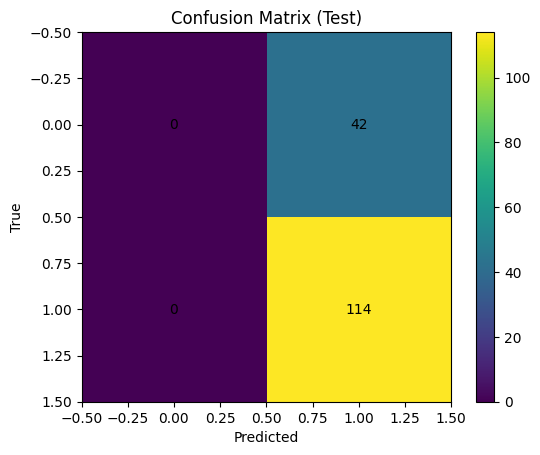

In [ ]:
# Confusion matrix visualization
import matplotlib.pyplot as plt
import numpy as np

plt.figure()
plt.imshow(test_cm)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
for (i, j), v in np.ndenumerate(test_cm):
    plt.text(j, i, str(v), ha="center", va="center")
plt.show()

## Transformers  for Qwen


In [ ]:
!pip -q install -U transformers accelerate


In [ ]:
# Load Qwen via Transformers
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

QWEN_HF_MODEL = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(QWEN_HF_MODEL, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    QWEN_HF_MODEL,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
    device_map="auto",
    trust_remote_code=True
)

def qwen_hf(prompt, max_new_tokens=200):
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=True, temperature=0.7)
    return tokenizer.decode(out[0], skip_special_tokens=True)

print(qwen_hf("Write a short, clinician-friendly definition of sensitivity and specificity."))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Write a short, clinician-friendly definition of sensitivity and specificity. Sensitivity refers to the proportion of true positive results among all actual cases in a test or diagnostic tool, indicating how well it identifies those who have the condition being tested for (true positives). Specificity, on the other hand, is the proportion of true negative results among all individuals without the condition, representing the accuracy at correctly identifying those who do not have the condition (true negatives).

This concise explanation captures the essence of both terms with clarity suitable for clinicians.


In [ ]:
print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


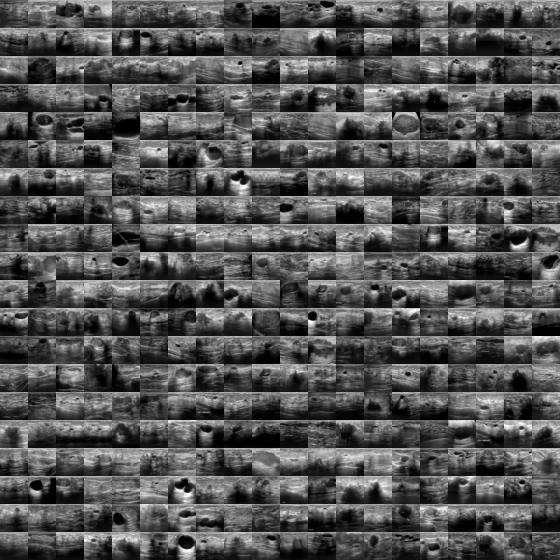

In [ ]:
# visualization

train_dataset.montage(length=20)

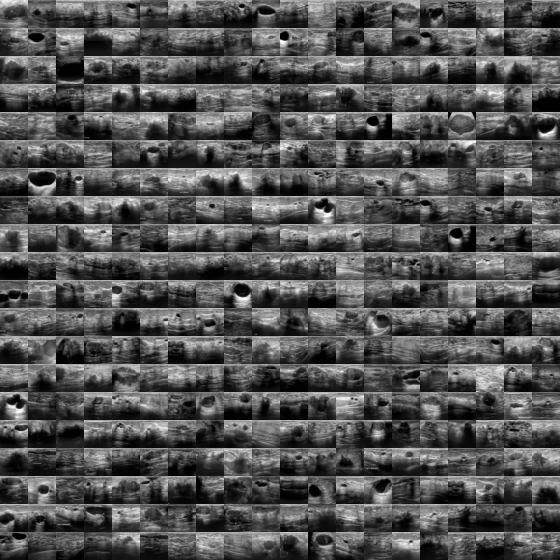

In [ ]:
# montage

train_dataset.montage(length=20)

In [ ]:
train_dataset.labels

array([[1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [0],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [0],
       [1],
       [0],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
       [1],
    

##  Using Qwen to write a short summary


In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-3B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

print("Qwen loaded successfully with Hugging Face Transformers")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen loaded successfully with Hugging Face Transformers


In [ ]:
!pip -q install transformers accelerate sentencepiece

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",
    torch_dtype="auto"
)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

In [ ]:
def qwen_hf(prompt, max_new_tokens=220):
    messages = [
        {
            "role": "system",
            "content": "You are assisting a medical imaging research trainee. Write clearly, cautiously, and in clinician-friendly language."
        },
        {
            "role": "user",
            "content": prompt
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(text, return_tensors="pt").to(model.device)

    outputs = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=True,
        temperature=0.7
    )

    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:],
        skip_special_tokens=True
    )
    return response

In [ ]:
# BreastMNIST label mapping:
# 0 = malignant
# 1 = normal / benign

tn_like = int(test_cm[0, 0])  # malignant predicted malignant
fn = int(test_cm[0, 1])       # malignant predicted benign
fp = int(test_cm[1, 0])       # benign predicted malignant
tp_like = int(test_cm[1, 1])  # benign predicted benign

results_text = (
    "BreastMNIST CNN baseline results:\n"
    f"- Test Accuracy: {test_acc:.4f}\n"
    f"- Test ROC-AUC: {test_auc:.4f}\n"
    f"- Confusion Matrix: {test_cm.tolist()}\n"
    f"- Label mapping: 0 = malignant, 1 = normal/benign\n"
    f"- Malignant correctly predicted as malignant: {tn_like}\n"
    f"- Malignant misclassified as benign (false negatives): {fn}\n"
    f"- Benign misclassified as malignant (false positives): {fp}\n"
    f"- Benign correctly predicted as benign: {tp_like}\n"
    f"- Total test samples: {len(test_y)}\n"
)

prompt = f"""
You are assisting a medical imaging research trainee.

Write a concise 120-160 word summary of the CNN results for a research supervisor.

Requirements:
- Use clinician-friendly language
- Mention test accuracy and ROC-AUC
- Explain the confusion matrix in plain terms
- Explicitly state that malignant cases predicted as benign are false negatives
- Highlight why false negatives are important in cancer detection
- Use the exact counts provided below
- Do not invent numbers
- Avoid hype
- Do not claim clinical deployment or clinical readiness

Results:
{results_text}
"""

summary = qwen_hf(prompt, max_new_tokens=220)
print(summary)

The BreastMNIST CNN baseline achieved an overall test accuracy of 73% with a ROC-AUC score of 68%. The confusion matrix shows that out of 156 total test samples:

- 0 were classified correctly as malignant,
- 42 were incorrectly labeled as benign (false negatives),
- 0 were incorrectly labeled as malignant (no true negative),
- 114 were correctly identified as benign.

This highlights that while the model is effective at predicting malignancy, it struggles to accurately identify benign lesions due to high false negative rates. This is particularly concerning in cancer detection where missed detections can lead to delayed treatment. The importance of these findings lies in improving diagnostic tools for better patient care.
